# Lab4_2024

In [1]:
def generate_func(school_number):
    '''
    根据学⽣学号⽣成抛物线函数及其导函数、迭代函数。
    参数:
    school_number (int): CIT学号，应为8位数字。
    返回:
    tuple: 包含三个函数
        第⼀个是⽣成的抛物线函数（⽬标函数）
        第⼆个是该函数的导函数
        第三个是从函数推导的不动点迭代函数
    示例:
    my_f, my_df, my_g = generate_func(22030501)
    然后可以使⽤ my_f(x) 和 my_df(x) 来计算函数值和导函数值。
    在不动点迭代时，可以⽤ my_g(x) 来进⾏不动点迭代。
    '''
    # 确保输⼊是⼀个8位的整数
    school_number_str = str(school_number)
    if len(school_number_str) != 8:
        raise ValueError("学号应为8位数字")
    # 从学号中提取系数
    a = int(school_number_str[3])
    b = int(school_number_str[5])
    c = int(school_number_str[6:]) / 10
    # 定义⼀个抛物线函数（⽬标函数）及其导函数
    f = lambda x: a * x**2 + b * x - c
    df = lambda x: 2 * a * x + b
    # 定义从⽬标函数推得的⼀个⽤于不动点迭代的函数
    g = lambda x: c / (a * x + b)
    return f, df, g

### 1. 向前差分公式
向前差分公式利用当前点和下一个点来近似导数，公式如下：

$$
f'(x) \approx \frac{f(x + h) - f(x)}{h}
$$

实现代码如下：

In [2]:
def ndiff_forward(f, x, h=0.1):
    """
    向前差分公式计算函数 f 在点 x 处的导数近似值。
    
    参数:
        f (function): 被求导的函数。
        x (float): 求导点。
        h (float): 差分步长。
    
    返回:
        float: 导数的近似值。
    """
    return (f(x + h) - f(x)) / h

### 2. 非对称三点公式（端点式）

非对称三点公式使用三个点来估计导数，公式如下：

$$
f'(x) \approx \frac{-3f(x) + 4f(x + h) - f(x + 2h)}{2h}
$$

实现代码如下：

In [3]:
def ndiff_three_point(f, x, h=0.1):
    """
    非对称三点公式计算函数 f 在点 x 处的导数近似值。
    
    参数:
        f (function): 被求导的函数。
        x (float): 求导点。
        h (float): 差分步长。
    
    返回:
        float: 导数的近似值。
    """
    return (-3 * f(x) + 4 * f(x + h) - f(x + 2 * h)) / (2 * h)


### 3. 对称五点公式（中点式）

对称五点公式使用五个点来估计导数，公式如下：

$$
f'(x) \approx \frac{f(x - 2h) - 8f(x - h) + 8f(x + h) - f(x + 2h)}{12h}
$$

实现代码如下：


In [4]:
def ndiff_five_point(f, x, h=0.1):
    """
    对称五点公式计算函数 f 在点 x 处的导数近似值。
    
    参数:
        f (function): 被求导的函数。
        x (float): 求导点。
        h (float): 差分步长。
    
    返回:
        float: 导数的近似值。
    """
    return (f(x - 2 * h) - 8 * f(x - h) + 8 * f(x + h) - f(x + 2 * h)) / (12 * h)


In [5]:
my_func = generate_func(school_number=23030320)[0]

# 设定求导点和步长
x = 1.0
h = 0.1

# 计算各方法的导数
forward_result = ndiff_forward(my_func, x, h)
three_point_result = ndiff_three_point(my_func, x, h)
five_point_result = ndiff_five_point(my_func, x, h)

# 输出结果
print("向前差分公式导数近似值:", forward_result)
print("非对称三点公式导数近似值:", three_point_result)
print("对称五点公式导数近似值:", five_point_result)

向前差分公式导数近似值: 9.300000000000015
非对称三点公式导数近似值: 9.00000000000003
对称五点公式导数近似值: 9.000000000000004


### 1. 简单 Simpson 公式
简单 Simpson 公式利用抛物线拟合积分区间，适用于积分区间有两个端点和一个中点的情形。

In [6]:
def nint_simpson_simple(f, a, b):
    """
    使用简单 Simpson 公式计算函数 f 在区间 [a, b] 上的近似积分。
    
    参数:
        f (function): 被积分的函数。
        a (float): 积分区间的起点。
        b (float): 积分区间的终点。
    
    返回:
        float: 积分的近似值。
    """
    c = (a + b) / 2  # 中点
    return (b - a) / 6 * (f(a) + 4 * f(c) + f(b))

### 2. 复合梯形公式
复合梯形公式将积分区间等距划分为多个小区间，在每个小区间上应用梯形法进行积分。结果是每段积分的总和。

In [7]:
def nint_trapezoidal_composite(f, a, b, n):
    """
    使用复合梯形公式计算函数 f 在区间 [a, b] 上的近似积分。
    
    参数:
        f (function): 被积分的函数。
        a (float): 积分区间的起点。
        b (float): 积分区间的终点。
        n (int): 区间划分的子区间数。
    
    返回:
        float: 积分的近似值。
    """
    h = (b - a) / n  # 每个子区间的宽度
    integral = 0.5 * (f(a) + f(b))  # 首尾点各取一半

    for i in range(1, n):
        integral += f(a + i * h)
    
    integral *= h
    return integral

### 3. 简单梯形公式 `nint_trapezoidal_simple`

简单梯形公式使用积分区间的两个端点进行计算：

$$
\int_a^b f(x) \, dx \approx \frac{b - a}{2} \times (f(a) + f(b))
$$

代码实现如下：

In [8]:
def nint_trapezoidal_simple(f, a, b):
    """
    使用简单梯形公式计算函数 f 在区间 [a, b] 上的近似积分。
    
    参数:
        f (function): 被积分的函数。
        a (float): 积分区间的起点。
        b (float): 积分区间的终点。
    
    返回:
        float: 积分的近似值。
    """
    return (b - a) / 2 * (f(a) + f(b))

### 4. 近似计算 `my_dfunc` 的积分

In [9]:
my_dfunc = generate_func(school_number=23030320)[1]

# 积分区间
a, b = 0, 1
h = 0.1
n = int((b - a) / h)  # 子区间数，用于复合梯形公式

# 使用简单梯形公式计算积分
simple_trap_result = nint_trapezoidal_simple(my_dfunc, a, b)

# 使用简单 Simpson 公式计算积分
simple_simpson_result = nint_simpson_simple(my_dfunc, a, b)

# 使用复合梯形公式计算积分
composite_trap_result = nint_trapezoidal_composite(my_dfunc, a, b, n)

# 打印结果
print("简单梯形公式积分结果:", simple_trap_result)
print("简单 Simpson 公式积分结果:", simple_simpson_result)
print("复合梯形公式积分结果:", composite_trap_result)


简单梯形公式积分结果: 6.0
简单 Simpson 公式积分结果: 6.0
复合梯形公式积分结果: 6.000000000000001


### 1. 实现四阶 Runge-Kutta 方法 `rk4_step`

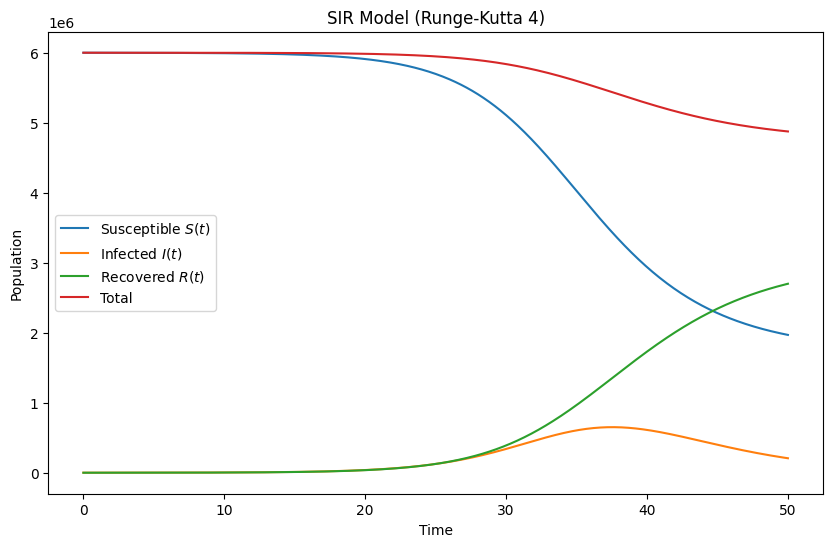

In [10]:
import numpy as np

# 定义SIR模型微分方程组
def sir_model(t, y, beta, rho, mu):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - (rho + mu) * I
    dRdt = rho * I
    return np.array([dSdt, dIdt, dRdt])

# 定义四阶 Runge-Kutta 步骤
def rk4_step(w, t, h, f, *args):
    k1 = f(t, w, *args)
    k2 = f(t + h / 2, w + h * k1 / 2, *args)
    k3 = f(t + h / 2, w + h * k2 / 2, *args)
    k4 = f(t + h, w + h * k3, *args)
    w_next = w + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return w_next

# 测试四阶 Runge-Kutta 方法
def solve_sir(method, S0, I0, R0, beta, rho, mu, dt, T):
    t = np.arange(0, T + dt, dt)
    w = np.zeros((len(t), 3))
    w[0, :] = [S0, I0, R0]
    
    for i in range(1, len(t)):
        w[i] = method(w[i-1], t[i-1], dt, sir_model, beta, rho, mu)
    
    return t, w

# 参数设置
beta = 9.906e-8    # 局部感染率
rho = 0.24         # 诊断率
mu = 0.1           # 感染者的死亡率
S0 = 6e6           # 初始易感人群数
I0 = 245           # 初始感染人群数
R0 = 0             # 初始康复人群数
dt = 0.1           # 步长
T = 50             # 模拟时间

# 使用四阶 Runge-Kutta 方法求解
t, w = solve_sir(rk4_step, S0, I0, R0, beta, rho, mu, dt, T)

# 可视化结果
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(t, w[:, 0], label='Susceptible $S(t)$')
plt.plot(t, w[:, 1], label='Infected $I(t)$')
plt.plot(t, w[:, 2], label='Recovered $R(t)$')
plt.plot(t, np.sum(w, axis=1), label='Total')
plt.title('SIR Model (Runge-Kutta 4)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()


### 2. 参数拟合优化

为了拟合 \(\beta\)、\(\rho\)、\(\mu\) 参数，我们使用最小二乘法，使预测的 \(S(t)\)、\(I(t)\)、\(R(t)\) 曲线与观测数据的误差最小。

优化后的参数：β = 9.906e-08, ρ = 0.24, μ = 0.1


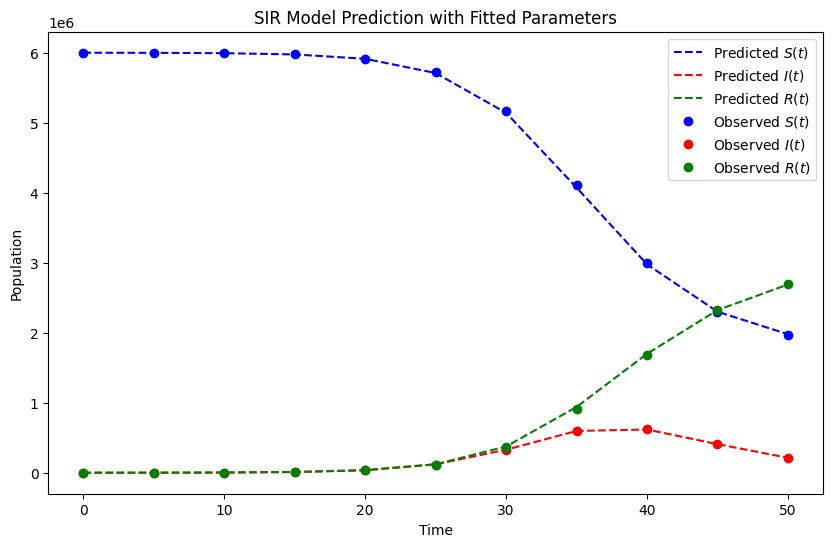

In [11]:
from scipy.optimize import minimize

# 观测数据
S_obs = np.array([6000000, 5998562, 5993524, 5975937, 5915474, 5717962, 5166337, 
                  4110774, 2993076, 2298680, 1969285])
I_obs = np.array([245, 859, 3014, 10515, 36078, 117077, 320886, 
                  593843, 625901, 416714, 216109])
R_obs = np.array([0, 580, 2616, 9735, 34370, 116614, 362132, 
                  914560, 1680894, 2318717, 2692835])
obs_length = len(S_obs)
dt = 5  # 每5天一个观测点
T_obs = dt * (obs_length - 1)

# 定义误差函数
def error(params):
    beta, rho, mu = params
    t, w = solve_sir(rk4_step, S0, I0, R0, beta, rho, mu, dt, T_obs)
    S_pred, I_pred, R_pred = w[::int(5/dt), 0], w[::int(5/dt), 1], w[::int(5/dt), 2]
    error = np.sum((S_obs - S_pred) ** 2 + (I_obs - I_pred) ** 2 + (R_obs - R_pred) ** 2)
    return error

# 设置初始猜测值和参数范围
initial_guess = [beta, rho, mu]
bounds = [(1e-10, 1e-2), (1e-4, 0.5), (1e-5, 0.5)]

# 优化参数
result = minimize(error, initial_guess, bounds=bounds)
beta_opt, rho_opt, mu_opt = result.x
print(f"优化后的参数：β = {beta_opt}, ρ = {rho_opt}, μ = {mu_opt}")

# 代入优化参数，进行预测
t, w = solve_sir(rk4_step, S0, I0, R0, beta_opt, rho_opt, mu_opt, dt, T)

# 绘制预测模型和观测值
plt.figure(figsize=(10, 6))
plt.plot(t, w[:, 0], 'b--', label='Predicted $S(t)$')
plt.plot(t, w[:, 1], 'r--', label='Predicted $I(t)$')
plt.plot(t, w[:, 2], 'g--', label='Predicted $R(t)$')
plt.plot(np.arange(0, T_obs + dt, dt), S_obs, 'bo', label='Observed $S(t)$')
plt.plot(np.arange(0, T_obs + dt, dt), I_obs, 'ro', label='Observed $I(t)$')
plt.plot(np.arange(0, T_obs + dt, dt), R_obs, 'go', label='Observed $R(t)$')
plt.title('SIR Model Prediction with Fitted Parameters')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()
